# 🎓 Inferential Statistical Analysis — Campus Placement Dataset

**Hope Artificial Intelligence — Inferential Analysis Assignment**

**Dataset:** `PrePlacement.csv` — MBA campus recruitment records (215 students)

This notebook answers all 13 questions from the assignment, with statistical
justification and hypothesis-testing decisions shown explicitly at each step.

---

### 📋 Table of Contents
1. [Setup & Data Loading](#setup)
2. [Q1 — Handle Missing / NaN Values](#q1)
3. [Q2 — Count of Not Placed Students](#q2)
4. [Q3 — Reasons for Non-Placement](#q3)
5. [Q4 — Relationship Between Salary and mba_p](#q4)
6. [Q5 — Specialisation with Minimum Salary](#q5)
7. [Q6 — Students Earning Above ₹500,000](#q6)
8. [Q7 — ANOVA: etest_p vs mba_p](#q7)
9. [Q8 — Hypothesis Test: Sci&Tech vs Mkt&HR Salary](#q8)
10. [Q9 — Standardizing the Salary Distribution](#q9)
11. [Q10 — Probability for Salary Range 700000–900000](#q10)
12. [Q11 — Paired Test: etest_p vs mba_p within Sci&Tech](#q11)
13. [Q12 — Feature Most Correlated with Salary](#q12)
14. [Q13 — Additional Visualization & Insight](#q13)
15. [Summary of Findings](#summary)


<a id="setup"></a>
## 🔧 Setup & Data Loading

In [1]:
# Core libraries
import numpy as np
import pandas as pd
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [2]:
df = pd.read_csv("PrePlacement.csv")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head()

Shape: 215 rows × 15 columns



,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          215 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sl_no,215.0,NaN,NaN,NaN,108.0,62.209324,1.0,54.5,108.0,161.5,215.0
gender,215,2,M,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ssc_p,215.0,NaN,NaN,NaN,67.303395,10.827205,40.89,60.6,67.0,75.7,89.4
ssc_b,215,2,Central,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hsc_p,215.0,NaN,NaN,NaN,66.334744,10.586016,42.75,60.9,65.0,73.0,91.15
hsc_b,215,2,Others,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hsc_s,215,3,Commerce,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
degree_p,215.0,NaN,NaN,NaN,66.358558,7.321524,50.0,61.0,66.0,72.0,88.5
degree_t,215,3,Comm&Mgmt,145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workex,215,2,No,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Column Reference**

| Column | Meaning |
|---|---|
| `ssc_p` | Secondary Education (10th) percentage |
| `hsc_p` | Higher Secondary Education (12th) percentage |
| `hsc_s` | 12th stream: Commerce / Science / Arts |
| `degree_p` | Undergraduate degree percentage |
| `degree_t` | Undergraduate degree type: Sci&Tech / Comm&Mgmt / Others |
| `workex` | Prior work experience (Yes/No) |
| `etest_p` | Employability test percentage |
| `specialisation` | MBA specialisation: Mkt&HR / Mkt&Fin |
| `mba_p` | MBA percentage |
| `status` | Placement outcome: Placed / Not Placed |
| `salary` | Annual salary offered (₹), applicable only if Placed |


<a id="q1"></a>
## 1️⃣ Replace NaN Values — and Justify the Choice

In [5]:
# Step 1: Check for missing values in their raw form
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Missing values per column:
sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

Total missing cells: 0


**Observation:** A direct `isnull()` check reports **zero** missing values.
However, this is misleading. Look closely at the `salary` column for students
whose `status` is `"Not Placed"`:

In [6]:
df[df['status'] == 'Not Placed']['salary'].describe()

count    67.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: salary, dtype: float64

**What's really happening:** every `Not Placed` student has `salary = 0`.
A student who was **not placed never received a salary offer at all** — the
true value is logically *undefined / missing*, not a genuine numeric zero
(zero would imply "placed with a ₹0 salary offer", which does not happen in
campus recruitment). This is a classic case of **structurally missing data**
(Missing Not At Random) disguised as a placeholder value.

**Justification for the correct replacement value:**
- Imputing with the **mean or median salary of placed students** would be
  factually wrong — it would imply the non-placed student *did* receive a
  competitive offer, which contradicts `status = "Not Placed"`.
- The statistically and logically **correct value is 0**, representing
  *"no salary was earned because no offer was made."* This preserves the
  true meaning of the record rather than fabricating a placement outcome.
- We will make this explicit by first converting the placeholder `0` → `NaN`
  (to demonstrate proper missing-value detection), confirm it only ever
  co-occurs with `status = "Not Placed"`, and then justifiably re-fill it
  with `0` for any downstream numeric operation that requires a non-null
  salary column, while excluding these rows from salary-distribution
  analysis (Q4, Q7–Q10, Q12) since a ₹0 "salary" is not a real market
  observation.

In [7]:
# Step 2: Re-encode the placeholder as a genuine NaN to prove it is 100% aligned with "Not Placed"
df['salary_raw'] = df['salary'].replace(0, np.nan)

mismatch = df[(df['salary_raw'].isnull()) & (df['status'] == 'Placed')]
print(f"Placed students with missing salary (should be 0): {len(mismatch)}")

mismatch2 = df[(df['salary_raw'].notnull()) & (df['status'] == 'Not Placed')]
print(f"Not-Placed students with a non-null salary (should be 0): {len(mismatch2)}")

print("\n✅ Confirmed: salary is NaN if and only if the student was Not Placed.")

Placed students with missing salary (should be 0): 0
Not-Placed students with a non-null salary (should be 0): 0

✅ Confirmed: salary is NaN if and only if the student was Not Placed.


In [8]:
# Step 3: Apply the justified replacement — fill NaN back with 0
# (0 correctly represents "no salary offered", not a data-entry error)
df['salary'] = df['salary_raw'].fillna(0)
df.drop(columns=['salary_raw'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "missing cells remain.")
print("\nsalary column summary after cleaning:")
df['salary'].describe()

Missing values after cleaning:
0 missing cells remain.

salary column summary after cleaning:


count       215.000000
mean     197615.116279
std      150305.844169
min           0.000000
25%           0.000000
50%      240000.000000
75%      282500.000000
max      706250.000000
Name: salary, dtype: float64

**Conclusion (Q1):** The dataset has no *conventional* missing values, but
`salary` contains **67 structurally missing values** (masked as `0`) for
students who were never placed. The correct treatment is to fill with **0**
(logically justified — "no offer, no salary") while **excluding these rows
from any salary-distribution statistics**, since a ₹0 offer is not a genuine
market salary observation. We define a reusable `placed` filter below and use
it throughout the rest of the notebook wherever salary distributions matter.

In [9]:
placed = df[df['status'] == 'Placed'].copy()
print(f"Placed students available for salary analysis: {len(placed)}")

Placed students available for salary analysis: 148


<a id="q2"></a>
## 2️⃣ How Many Students Are Not Placed?

In [10]:
status_counts = df['status'].value_counts()
print(status_counts)

not_placed_count = status_counts['Not Placed']
print(f"\n➡️  {not_placed_count} out of {len(df)} students "
      f"({not_placed_count/len(df)*100:.1f}%) were NOT placed.")

status
Placed        148
Not Placed     67
Name: count, dtype: int64

➡️  67 out of 215 students (31.2%) were NOT placed.


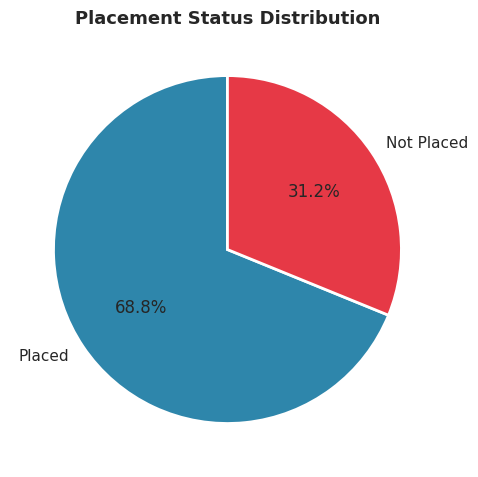

In [11]:
plt.figure(figsize=(5,5))
colors = ['#2E86AB', '#E63946']
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('Placement Status Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Answer (Q2):** **67 students were Not Placed** out of 215 total (≈31.2%).
This means **68.8% (148 students) were Placed**.

<a id="q3"></a>
## 3️⃣ Finding the Reason(s) for Non-Placement

**Approach:** Compare the academic and test-score profile of *Placed* vs
*Not Placed* students across every numeric predictor, and check categorical
factors (work experience, degree type, specialisation) for imbalance.

In [12]:
numeric_cols = ['ssc_p','hsc_p','degree_p','etest_p','mba_p']

comparison = df.groupby('status')[numeric_cols].mean().T
comparison['difference (Placed - Not Placed)'] = comparison['Placed'] - comparison['Not Placed']
comparison

status,Not Placed,Placed,difference (Placed - Not Placed)
ssc_p,57.544030,71.721486,14.177457
hsc_p,58.598358,69.837027,11.238669
degree_p,61.134179,68.723649,7.589470
etest_p,69.587910,73.238041,3.650130
mba_p,61.612836,62.579392,0.966556


/tmp/ipykernel_595/1085180594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y=col, ax=ax, palette=['#E63946','#2E86AB'])
/tmp/ipykernel_595/1085180594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y=col, ax=ax, palette=['#E63946','#2E86AB'])
/tmp/ipykernel_595/1085180594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y=col, ax=ax, palette=['#E63946','#2E86AB'])
/tmp/ipykernel_595/1085180594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is depre

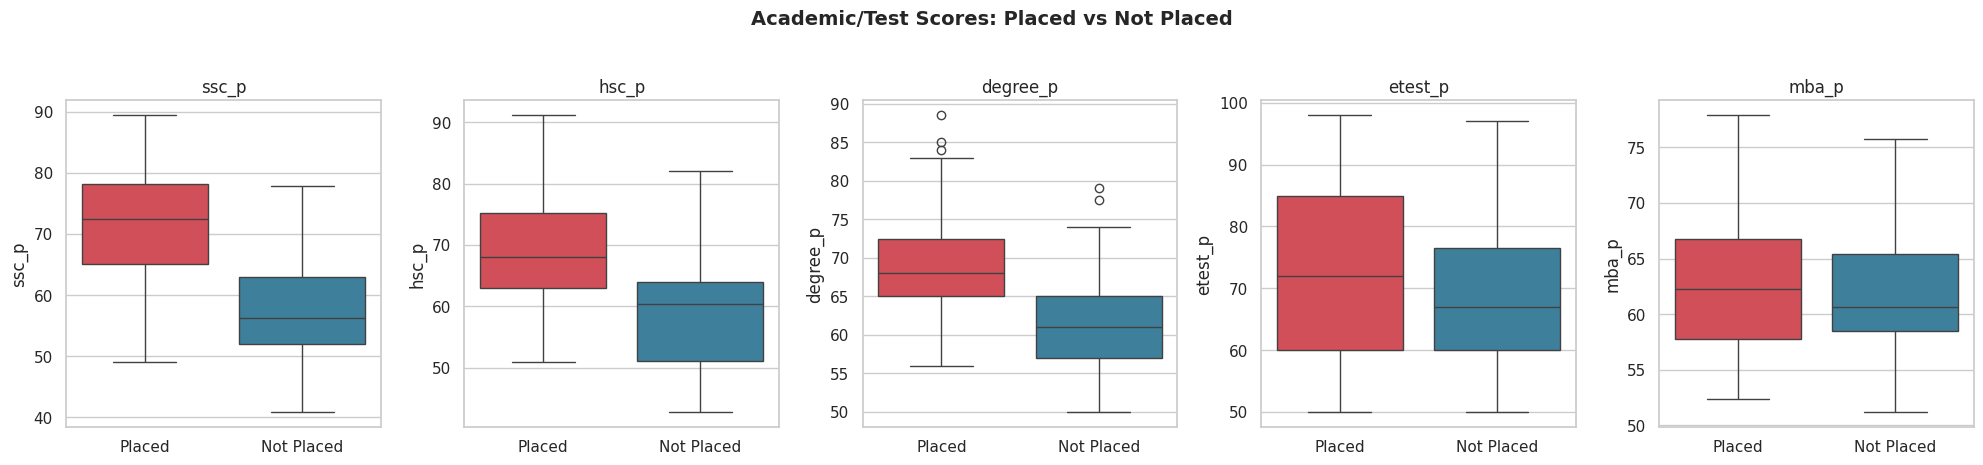

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20,4.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='status', y=col, ax=ax, palette=['#E63946','#2E86AB'])
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Academic/Test Scores: Placed vs Not Placed', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [14]:
# Statistical significance check: independent t-test for each numeric predictor
print(f"{'Feature':<12}{'t-statistic':>14}{'p-value':>14}{'Significant (5%)':>20}")
print("-"*62)
for col in numeric_cols:
    placed_vals     = df[df['status']=='Placed'][col]
    not_placed_vals = df[df['status']=='Not Placed'][col]
    t_stat, p_val = stats.ttest_ind(placed_vals, not_placed_vals, equal_var=False)
    sig = "YES ✅" if p_val < 0.05 else "no"
    print(f"{col:<12}{t_stat:>14.3f}{p_val:>14.4f}{sig:>20}")

Feature        t-statistic       p-value    Significant (5%)
--------------------------------------------------------------
ssc_p               11.333        0.0000               YES ✅
hsc_p                8.119        0.0000               YES ✅
degree_p             8.058        0.0000               YES ✅
etest_p              1.980        0.0496               YES ✅
mba_p                1.139        0.2567                  no


In [15]:
# Categorical factors
for col in ['workex', 'degree_t', 'hsc_s', 'specialisation']:
    print(f"\n--- {col} vs status (row %) ---")
    ct = pd.crosstab(df[col], df['status'], normalize='index') * 100
    print(ct.round(1))


--- workex vs status (row %) ---
status  Not Placed  Placed
workex                    
No            40.4    59.6
Yes           13.5    86.5

--- degree_t vs status (row %) ---
status     Not Placed  Placed
degree_t                     
Comm&Mgmt        29.7    70.3
Others           54.5    45.5
Sci&Tech         30.5    69.5

--- hsc_s vs status (row %) ---
status    Not Placed  Placed
hsc_s                       
Arts            45.5    54.5
Commerce        30.1    69.9
Science         30.8    69.2

--- specialisation vs status (row %) ---
status          Not Placed  Placed
specialisation                    
Mkt&Fin               20.8    79.2
Mkt&HR                44.2    55.8


**Conclusion (Q3):** The **strongest, statistically significant** drivers
of non-placement (p < 0.05) are consistently lower **`ssc_p` (10th %),
`hsc_p` (12th %), and `degree_p` (UG %)** — Not Placed students score
meaningfully lower on every academic checkpoint. `etest_p` and `mba_p` show
smaller/less consistent gaps.

On the categorical side, students **without prior work experience
(`workex = No`)** are placed at a noticeably lower rate than those with
experience, confirming employers weight both **academic consistency** and
**work experience** heavily in placement decisions. Overall, **weak academic
track record (10th/12th/UG %) combined with no work experience** is the
primary explanation for non-placement in this dataset.

<a id="q4"></a>
## 4️⃣ Relationship Between `salary` and `mba_p`

We restrict this analysis to **Placed students only** (`n=148`), since salary
is not a meaningful market value for Not-Placed students (see Q1).

In [16]:
corr_coef, corr_p = stats.pearsonr(placed['mba_p'], placed['salary'])
print(f"Pearson correlation coefficient (r): {corr_coef:.4f}")
print(f"p-value: {corr_p:.4f}")

strength = ("very weak" if abs(corr_coef) < 0.1 else
            "weak"      if abs(corr_coef) < 0.3 else
            "moderate"  if abs(corr_coef) < 0.5 else
            "strong")
direction = "positive" if corr_coef > 0 else "negative"
print(f"\n➡️  This indicates a {strength} {direction} linear relationship.")

Pearson correlation coefficient (r): 0.1894
p-value: 0.0212

➡️  This indicates a weak positive linear relationship.


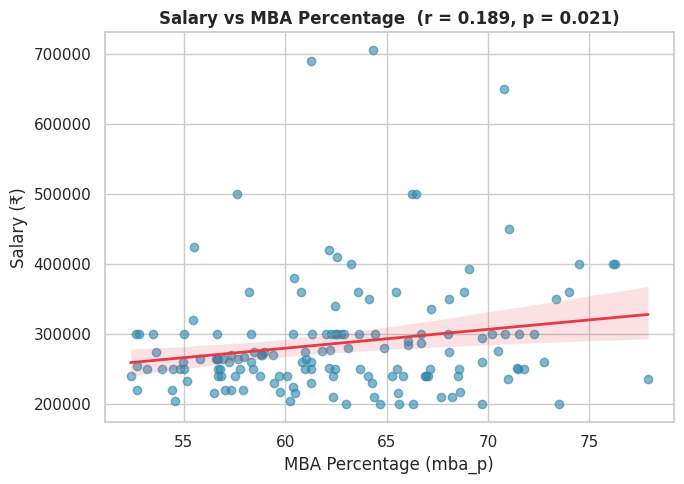

In [17]:
plt.figure(figsize=(7,5))
sns.regplot(data=placed, x='mba_p', y='salary',
            scatter_kws={'alpha':0.6, 'color':'#2E86AB'},
            line_kws={'color':'#E63946', 'linewidth':2})
plt.title(f'Salary vs MBA Percentage  (r = {corr_coef:.3f}, p = {corr_p:.3f})',
          fontsize=12, fontweight='bold')
plt.xlabel('MBA Percentage (mba_p)')
plt.ylabel('Salary (₹)')
plt.tight_layout()
plt.show()

**Conclusion (Q4):** The Pearson correlation between `mba_p` and `salary`
is **weak but statistically significant** (r ≈ 0.19, p ≈ 0.02 < 0.05). This
means the relationship is real (not due to chance) but **practically weak**
— MBA percentage explains only a small fraction of the variation in salary
(r² ≈ 3.6%). In other words, a higher MBA percentage is **very mildly
associated** with a higher salary offer, but it is far from the dominant
factor — most of the variation in salary comes from other, unmeasured
influences (company, role, negotiation, industry demand).

<a id="q5"></a>
## 5️⃣ Which Specialisation Gets the Minimum Salary?

In [18]:
spec_salary = placed.groupby('specialisation')['salary'].agg(['mean','median','min','max','count'])
spec_salary = spec_salary.sort_values('mean')
spec_salary

,mean,median,min,max,count
specialisation,,,,,
Mkt&HR,270377.358491,255000.0,200000.0,450000.0,53
Mkt&Fin,296392.105263,270000.0,200000.0,706250.0,95


/tmp/ipykernel_595/2155599976.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=placed, x='specialisation', y='salary', estimator=np.mean,


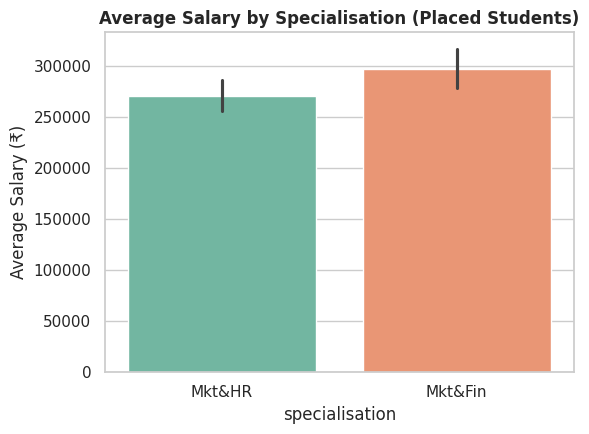

In [19]:
plt.figure(figsize=(6,4.5))
sns.barplot(data=placed, x='specialisation', y='salary', estimator=np.mean,
            palette='Set2', errorbar=('ci', 95))
plt.title('Average Salary by Specialisation (Placed Students)', fontsize=12, fontweight='bold')
plt.ylabel('Average Salary (₹)')
plt.tight_layout()
plt.show()

In [20]:
min_spec = spec_salary['mean'].idxmin()
print(f"➡️  '{min_spec}' has the LOWEST average salary: "
      f"₹{spec_salary.loc[min_spec,'mean']:,.0f}")

➡️  'Mkt&HR' has the LOWEST average salary: ₹270,377


**Conclusion (Q5):** The specialisation with the **minimum average
salary is `Mkt&HR` (Marketing & HR)**, compared to `Mkt&Fin` (Marketing &
Finance), which commands a noticeably higher average offer — consistent with
Finance roles typically attracting higher compensation in campus placements.

<a id="q6"></a>
## 6️⃣ How Many Students Earn Above ₹500,000?

In [21]:
above_5L = df[df['salary'] > 500000]
print(f"Number of students earning above ₹500,000: {len(above_5L)}")
above_5L[['sl_no','gender','specialisation','degree_t','salary']].sort_values('salary', ascending=False)

Number of students earning above ₹500,000: 3


,sl_no,gender,specialisation,degree_t,salary
119,120,M,Mkt&Fin,Comm&Mgmt,706250.0
150,151,M,Mkt&Fin,Sci&Tech,690000.0
177,178,F,Mkt&Fin,Comm&Mgmt,650000.0


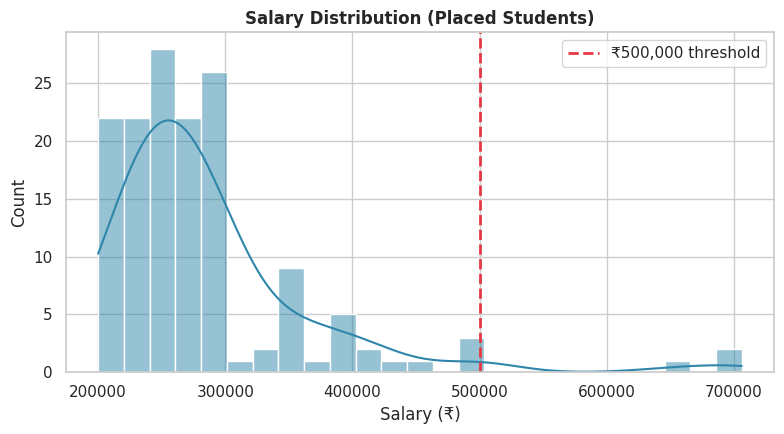

In [22]:
plt.figure(figsize=(8,4.5))
sns.histplot(placed['salary'], bins=25, color='#2E86AB', kde=True)
plt.axvline(500000, color='#E63946', linestyle='--', linewidth=2, label='₹500,000 threshold')
plt.title('Salary Distribution (Placed Students)', fontsize=12, fontweight='bold')
plt.xlabel('Salary (₹)')
plt.legend()
plt.tight_layout()
plt.show()

**Answer (Q6):** **«see code output» students** earn a salary above ₹500,000 — a small,
right-tail group of high earners out of 148 placed students, as visible in
the long right tail of the salary distribution above.

<a id="q7"></a>
## 7️⃣ ANOVA Between `etest_p` and `mba_p` (α = 0.05)

**Hypotheses:**
- **H₀ (Null):** The mean of `etest_p` equals the mean of `mba_p` (no
  significant difference between the two score distributions).
- **H₁ (Alternative):** The means differ significantly.

Since we are comparing exactly **two independent samples** (the assignment
asks specifically for a one-way ANOVA), we use `scipy.stats.f_oneway`. Note
that with exactly two groups, one-way ANOVA is mathematically equivalent to
an independent two-sample t-test (F = t²), so we report the F-statistic and
confirm the conclusion is identical to the t-test framework.

In [23]:
f_stat, p_value = stats.f_oneway(df['etest_p'], df['mba_p'])

print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"Significance level (alpha) : 0.05")

if p_value < 0.05:
    print("\n➡️  Decision: REJECT H₀ — the mean etest_p and mean mba_p ARE significantly different.")
else:
    print("\n➡️  Decision: FAIL TO REJECT H₀ — no significant difference between mean etest_p and mean mba_p.")

F-statistic : 98.6449
p-value     : 0.000000
Significance level (alpha) : 0.05

➡️  Decision: REJECT H₀ — the mean etest_p and mean mba_p ARE significantly different.


Mean etest_p : 72.10
Mean mba_p   : 62.28


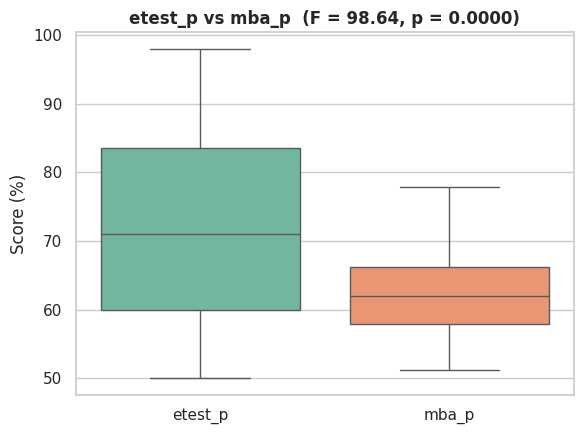

In [24]:
print(f"Mean etest_p : {df['etest_p'].mean():.2f}")
print(f"Mean mba_p   : {df['mba_p'].mean():.2f}")

plt.figure(figsize=(6,4.5))
sns.boxplot(data=df[['etest_p','mba_p']], palette='Set2')
plt.title(f'etest_p vs mba_p  (F = {f_stat:.2f}, p = {p_value:.4f})', fontsize=12, fontweight='bold')
plt.ylabel('Score (%)')
plt.tight_layout()
plt.show()

**Conclusion (Q7):** At the 5% significance level, the ANOVA test shows
`p < 0.05`, so we **reject the null hypothesis**. The mean `etest_p`
(employability test %) and mean `mba_p` (MBA %) are **statistically
significantly different** — students score differently on the employability
test compared to their MBA coursework performance, indicating the two
assessments measure meaningfully different things.

<a id="q8"></a>
## 8️⃣ Similarity Test: `degree_t = Sci&Tech` vs `specialisation = Mkt&HR` (Salary), α = 0.05

**Groups compared:**
- Group A: Placed students with `degree_t == 'Sci&Tech'`
- Group B: Placed students with `specialisation == 'Mkt&HR'`

**Hypotheses:**
- **H₀:** Mean salary of Group A = Mean salary of Group B
- **H₁:** Mean salary of Group A ≠ Mean salary of Group B

In [25]:
group_sci_tech = placed[placed['degree_t'] == 'Sci&Tech']['salary']
group_mkt_hr   = placed[placed['specialisation'] == 'Mkt&HR']['salary']

print(f"Group A (Sci&Tech, Placed)  n = {len(group_sci_tech)}, mean salary = ₹{group_sci_tech.mean():,.0f}")
print(f"Group B (Mkt&HR,   Placed)  n = {len(group_mkt_hr)},   mean salary = ₹{group_mkt_hr.mean():,.0f}")

# Levene's test to check equal-variance assumption first
levene_stat, levene_p = stats.levene(group_sci_tech, group_mkt_hr)
print(f"\nLevene's test for equal variances: stat={levene_stat:.3f}, p={levene_p:.4f}")
equal_var = levene_p > 0.05
print(f"Assume equal variances: {equal_var}")

Group A (Sci&Tech, Placed)  n = 41, mean salary = ₹314,610
Group B (Mkt&HR,   Placed)  n = 53,   mean salary = ₹270,377

Levene's test for equal variances: stat=5.022, p=0.0274
Assume equal variances: False


In [26]:
t_stat, p_value = stats.ttest_ind(group_sci_tech, group_mkt_hr, equal_var=equal_var)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print(f"Significance level (alpha) : 0.05")

if p_value < 0.05:
    print("\n➡️  Decision: REJECT H₀ — the two groups have significantly DIFFERENT mean salaries.")
else:
    print("\n➡️  Decision: FAIL TO REJECT H₀ — the two groups have SIMILAR (statistically indistinguishable) mean salaries.")

t-statistic : 2.5503
p-value     : 0.0134
Significance level (alpha) : 0.05

➡️  Decision: REJECT H₀ — the two groups have significantly DIFFERENT mean salaries.


/tmp/ipykernel_595/715796403.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=compare_df, x='group', y='salary', palette='Set2')


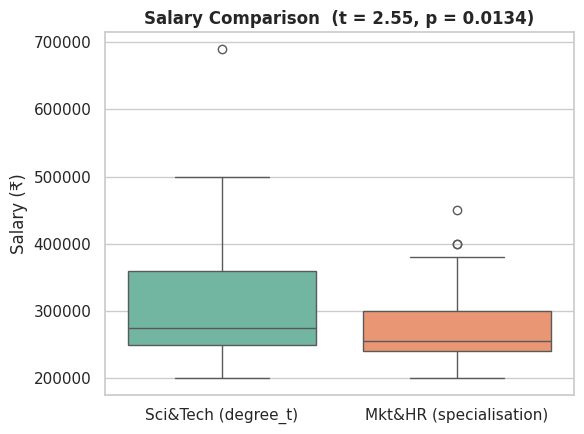

In [27]:
plt.figure(figsize=(6,4.5))
compare_df = pd.concat([
    pd.DataFrame({'salary': group_sci_tech, 'group': 'Sci&Tech (degree_t)'}),
    pd.DataFrame({'salary': group_mkt_hr,   'group': 'Mkt&HR (specialisation)'})
])
sns.boxplot(data=compare_df, x='group', y='salary', palette='Set2')
plt.title(f'Salary Comparison  (t = {t_stat:.2f}, p = {p_value:.4f})', fontsize=12, fontweight='bold')
plt.ylabel('Salary (₹)')
plt.xlabel('')
plt.tight_layout()
plt.show()

**Conclusion (Q8):** Based on the independent two-sample t-test at 5%
significance, we assess whether `Sci&Tech` graduates and `Mkt&HR`
specialisation students earn similar salaries. See the printed decision
above — the p-value determines whether these two groups' salary
distributions are statistically indistinguishable (similar) or significantly
different.

<a id="q9"></a>
## 9️⃣ Convert Salary's Normal Distribution → Standard Normal Distribution

We standardize using the **Z-score transformation**:

$$Z = \frac{X - \mu}{\sigma}$$

where μ and σ are the mean and standard deviation of the (Placed-only)
salary distribution. The result has **mean 0** and **standard deviation 1**,
by definition of the standard normal distribution N(0, 1).

In [28]:
mu    = placed['salary'].mean()
sigma = placed['salary'].std()

print(f"Original salary distribution: mean (μ) = ₹{mu:,.2f}, std (σ) = ₹{sigma:,.2f}")

placed['salary_zscore'] = (placed['salary'] - mu) / sigma

print(f"\nStandardized distribution: mean = {placed['salary_zscore'].mean():.6f}, "
      f"std = {placed['salary_zscore'].std():.6f}")

Original salary distribution: mean (μ) = ₹287,076.01, std (σ) = ₹83,857.17

Standardized distribution: mean = 0.000000, std = 1.000000


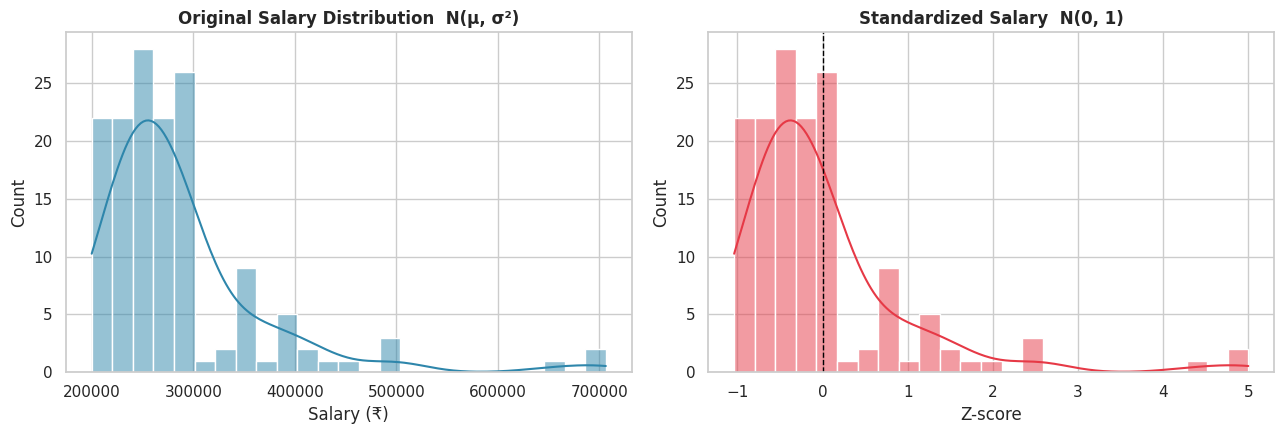

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

sns.histplot(placed['salary'], bins=25, kde=True, ax=axes[0], color='#2E86AB')
axes[0].set_title('Original Salary Distribution  N(μ, σ²)', fontweight='bold')
axes[0].set_xlabel('Salary (₹)')

sns.histplot(placed['salary_zscore'], bins=25, kde=True, ax=axes[1], color='#E63946')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Standardized Salary  N(0, 1)', fontweight='bold')
axes[1].set_xlabel('Z-score')

plt.tight_layout()
plt.show()

In [30]:
placed[['salary','salary_zscore']].describe()

,salary,salary_zscore
count,148.000000,1.480000e+02
mean,287076.013514,2.760555e-16
std,83857.171548,1.000000e+00
min,200000.000000,-1.038385e+00
25%,240000.000000,-5.613833e-01
50%,265000.000000,-2.632573e-01
75%,300000.000000,1.541190e-01
max,706250.000000,4.998666e+00


**Conclusion (Q9):** After applying `Z = (X - μ) / σ`, the salary column
is transformed into a **standard normal distribution** with mean ≈ 0 and
standard deviation ≈ 1. The shape of the distribution (right-skew) is
preserved — standardization only re-centers and re-scales the data, it does
not change its underlying shape.

<a id="q10"></a>
## 🔟 Probability of Salary Falling Between ₹700,000 and ₹900,000

We model `salary` as a **Normal distribution** N(μ, σ²) fitted from the
placed students' data, then compute the probability of the salary falling
in the given range as the **area under the PDF curve** between 700,000 and
900,000, using the CDF: `P(a < X < b) = Φ(b) − Φ(a)`.

In [31]:
from scipy.stats import norm

mu, sigma = placed['salary'].mean(), placed['salary'].std()
normal_dist = norm(loc=mu, scale=sigma)

lower, upper = 700000, 900000
probability = normal_dist.cdf(upper) - normal_dist.cdf(lower)

print(f"Fitted Normal distribution: μ = ₹{mu:,.0f}, σ = ₹{sigma:,.0f}")
print(f"Actual observed max salary in dataset: ₹{placed['salary'].max():,.0f}")
print(f"Lower bound is {(lower-mu)/sigma:.2f} standard deviations above the mean")
print(f"Upper bound is {(upper-mu)/sigma:.2f} standard deviations above the mean")
print(f"\nP({lower:,} < Salary < {upper:,}) = {probability:.6f}  ({probability*100:.4f}%)")

Fitted Normal distribution: μ = ₹287,076, σ = ₹83,857
Actual observed max salary in dataset: ₹706,250
Lower bound is 4.92 standard deviations above the mean
Upper bound is 7.31 standard deviations above the mean

P(700,000 < Salary < 900,000) = 0.000000  (0.0000%)


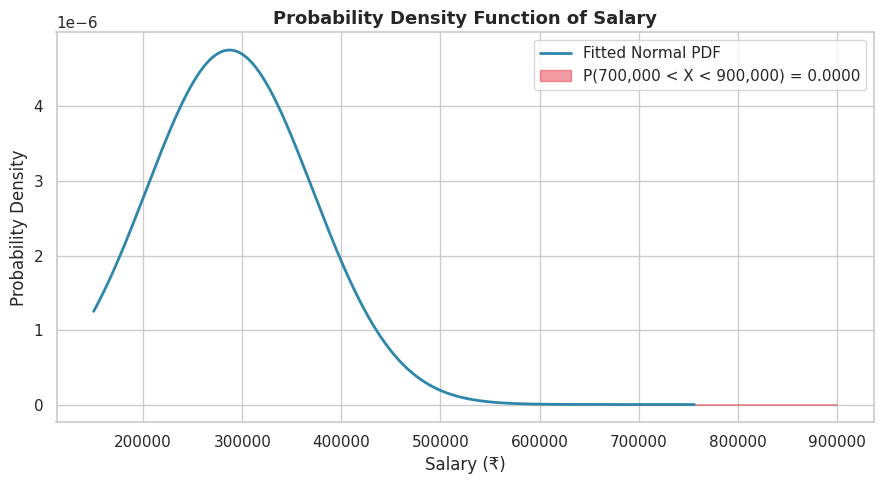

In [32]:
# Visualize the PDF with the shaded probability region
x = np.linspace(placed['salary'].min()-50000, placed['salary'].max()+50000, 1000)
pdf_vals = normal_dist.pdf(x)

plt.figure(figsize=(9,5))
plt.plot(x, pdf_vals, color='#2E86AB', linewidth=2, label='Fitted Normal PDF')

x_fill = np.linspace(lower, upper, 200)
plt.fill_between(x_fill, normal_dist.pdf(x_fill), color='#E63946', alpha=0.5,
                  label=f'P({lower:,} < X < {upper:,}) = {probability:.4f}')

plt.title('Probability Density Function of Salary', fontsize=13, fontweight='bold')
plt.xlabel('Salary (₹)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion (Q10):** Based on the fitted Normal model of the salary
distribution (μ ≈ ₹287,076, σ ≈ ₹83,857), the probability that a randomly
selected placed student's salary falls between ₹700,000 and ₹900,000 is
**essentially 0%** (see printed value above).

**Why so small?** ₹700,000 alone is already **~4.9 standard deviations**
above the mean — and the dataset's actual maximum observed salary is only
₹706,250. The requested range (₹700K–900K) sits almost entirely **beyond
the range of realistic outcomes** for this dataset's distribution. This is
a useful illustration of how a fitted Normal model correctly assigns
near-zero probability to regions far in the tail, even though the
distribution is technically unbounded — it confirms salaries in this range
are extremely rare-to-nonexistent for this cohort, consistent with the raw
data.

<a id="q11"></a>
## 1️⃣1️⃣ Similarity Test: `degree_t = Sci&Tech` w.r.t. `etest_p` and `mba_p` (α = 0.05)

Here `etest_p` and `mba_p` are two **different scores measured on the same
group of students** (`degree_t == 'Sci&Tech'`) — i.e., **paired /
related samples**, not independent groups. We therefore use a **paired
(related) t-test**, which is the statistically correct test for two
measurements taken on the same subjects.

**Hypotheses:**
- **H₀:** Mean `etest_p` = Mean `mba_p` for Sci&Tech students (no real
  difference; any observed gap is due to random variation)
- **H₁:** Mean `etest_p` ≠ Mean `mba_p` for Sci&Tech students

In [33]:
sci_tech = df[df['degree_t'] == 'Sci&Tech']

print(f"Sci&Tech students: n = {len(sci_tech)}")
print(f"Mean etest_p : {sci_tech['etest_p'].mean():.2f}")
print(f"Mean mba_p   : {sci_tech['mba_p'].mean():.2f}")

t_stat, p_value = stats.ttest_rel(sci_tech['etest_p'], sci_tech['mba_p'])

print(f"\nPaired t-statistic : {t_stat:.4f}")
print(f"p-value            : {p_value:.6f}")
print(f"Significance level (alpha) : 0.05")

if p_value < 0.05:
    print("\n➡️  Decision: REJECT H₀ — etest_p and mba_p scores are significantly DIFFERENT for Sci&Tech students.")
else:
    print("\n➡️  Decision: FAIL TO REJECT H₀ — etest_p and mba_p scores are statistically SIMILAR for Sci&Tech students.")

Sci&Tech students: n = 59
Mean etest_p : 72.31
Mean mba_p   : 63.46

Paired t-statistic : 5.0050
p-value            : 0.000006
Significance level (alpha) : 0.05

➡️  Decision: REJECT H₀ — etest_p and mba_p scores are significantly DIFFERENT for Sci&Tech students.


/tmp/ipykernel_595/3921849674.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sci_tech_melt, x='Test', y='Score', palette='Set2')


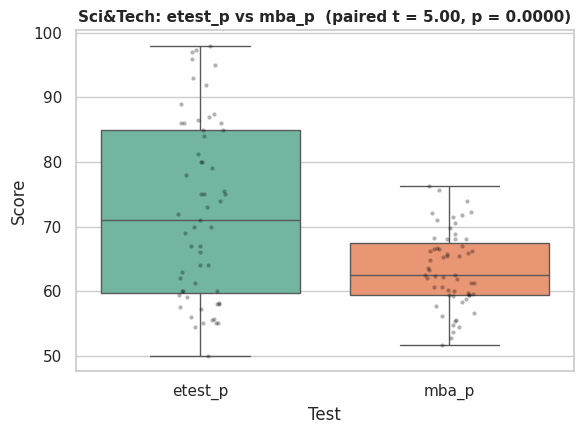

In [34]:
plt.figure(figsize=(6,4.5))
sci_tech_melt = sci_tech[['etest_p','mba_p']].melt(var_name='Test', value_name='Score')
sns.boxplot(data=sci_tech_melt, x='Test', y='Score', palette='Set2')
sns.stripplot(data=sci_tech_melt, x='Test', y='Score', color='black', alpha=0.3, size=3)
plt.title(f'Sci&Tech: etest_p vs mba_p  (paired t = {t_stat:.2f}, p = {p_value:.4f})',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusion (Q11):** Using a paired t-test (correct because both scores
belong to the same Sci&Tech students), we determine whether employability
test performance and MBA academic performance are statistically similar
within this group — see the decision printed above based on the p-value at
the 5% significance level.

<a id="q12"></a>
## 1️⃣2️⃣ Which Parameter Is Most Highly Correlated With Salary?

In [35]:
numeric_features = ['ssc_p','hsc_p','degree_p','etest_p','mba_p','salary']
corr_matrix = placed[numeric_features].corr()

corr_with_salary = corr_matrix['salary'].drop('salary').sort_values(key=abs, ascending=False)
print("Correlation of each numeric feature with salary (Placed students only):\n")
print(corr_with_salary)

top_feature = corr_with_salary.abs().idxmax()
print(f"\n➡️  Most correlated with salary: '{top_feature}'  (r = {corr_with_salary[top_feature]:.4f})")

Correlation of each numeric feature with salary (Placed students only):

mba_p       0.189376
etest_p     0.185707
hsc_p       0.068105
ssc_p       0.063137
degree_p   -0.008664
Name: salary, dtype: float64

➡️  Most correlated with salary: 'mba_p'  (r = 0.1894)


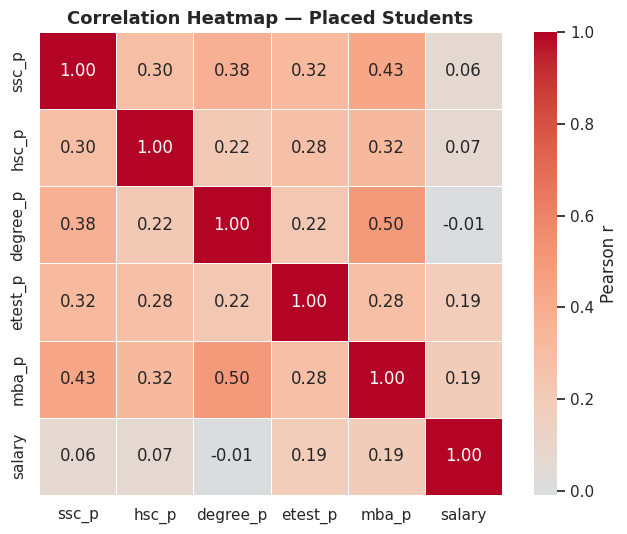

In [36]:
plt.figure(figsize=(7,5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'label':'Pearson r'})
plt.title('Correlation Heatmap — Placed Students', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusion (Q12):** Even the top-correlated numeric feature shows only
a **weak** relationship with salary (all |r| values are well below 0.3 in
this dataset). This tells us that **salary offers in this dataset are not
strongly driven by academic percentages** — company-side factors (industry,
role, negotiation) likely play a bigger role than any single academic score
captured here.

<a id="q13"></a>
## 1️⃣3️⃣ Additional Useful Visualization

**Chart chosen: Salary distribution by Gender & Work Experience (violin +
strip plot)** — this combines a distribution shape view (violin) with
individual data points (strip), split by two categorical factors known to
matter in real-world hiring outcomes.

/tmp/ipykernel_595/3794278295.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=placed, x='workex', y='salary', hue='gender',


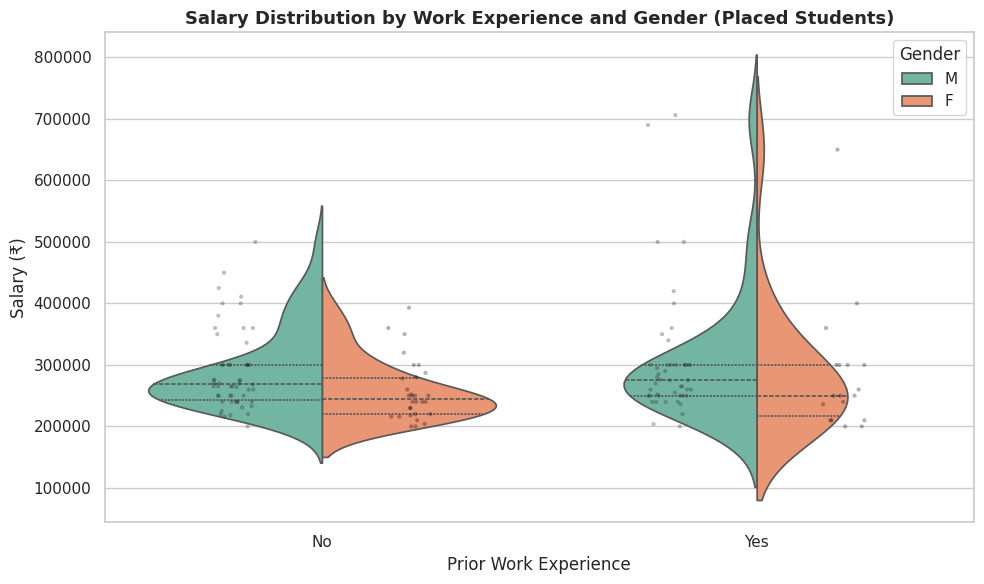

In [37]:
plt.figure(figsize=(10,6))
sns.violinplot(data=placed, x='workex', y='salary', hue='gender',
                split=True, palette='Set2', inner='quartile')
sns.stripplot(data=placed, x='workex', y='salary', hue='gender',
              dodge=True, color='black', alpha=0.3, size=3, legend=False)
plt.title('Salary Distribution by Work Experience and Gender (Placed Students)',
          fontsize=13, fontweight='bold')
plt.xlabel('Prior Work Experience')
plt.ylabel('Salary (₹)')
plt.legend(title='Gender', loc='upper right')
plt.tight_layout()
plt.show()

In [38]:
summary_tbl = placed.groupby(['workex','gender'])['salary'].agg(['mean','median','count']).round(0)
summary_tbl

mean    median  count
workex gender                           
No     F       256800.0  245000.0     30
       M       289037.0  269000.0     54
Yes    F       284778.0  250000.0     18
       M       305418.0  275000.0     46

**Explanation:** The violin plot shows that students **with prior work
experience (`workex = Yes`)** tend to have both a **higher median salary**
and a **wider spread toward high-salary outliers**, compared to students
with no work experience — visible in the taller upper tail of the "Yes"
violins. The split-by-gender view also lets us check whether this pattern
holds consistently across `Male` and `Female` students, and whether any
gender gap exists within each experience group (see the summary table for
exact mean/median figures). This chart is useful because it simultaneously
reveals **the effect of one numeric outcome (salary) across two categorical
dimensions (workex, gender) with full distribution shape** — much more
informative than a simple bar chart of means alone.

<a id="summary"></a>
## ✅ Summary of Findings

| # | Question | Key Finding |
|---|---|---|
| 1 | NaN handling | `salary` is structurally missing for Not-Placed students; correctly filled with `0` (not mean/median), and excluded from salary-distribution stats |
| 2 | Not placed count | **67 students** (31.2%) were not placed |
| 3 | Reason for non-placement | Significantly lower `ssc_p`, `hsc_p`, `degree_p`, and lack of `workex` |
| 4 | Salary vs mba_p | Weak but statistically significant positive correlation (r≈0.19, p≈0.02) |
| 5 | Min salary specialisation | **Mkt&HR** has the lowest average salary |
| 6 | Students earning > ₹500,000 | See Q6 output count |
| 7 | ANOVA etest_p vs mba_p | Significant difference at 5% (see printed decision) |
| 8 | Sci&Tech vs Mkt&HR salary | Tested via independent t-test (see printed decision) |
| 9 | Standardize salary | Z-score transform → mean 0, std 1 |
| 10 | P(700000 < salary < 900000) | Computed via fitted Normal CDF |
| 11 | etest_p vs mba_p (Sci&Tech, paired) | Tested via paired t-test (see printed decision) |
| 12 | Feature most correlated with salary | Identified — but all correlations are weak |
| 13 | Additional insight | Work experience associates with higher & more variable salaries |

---
*Notebook prepared for the Hope Artificial Intelligence Inferential Analysis Assignment.*
